In [2]:
# Bibliotecas 

import cv2
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.datasets import load_iris

### 1. Conjunto de datos Iris

In [3]:
iris = load_iris()

df_iris = pd.DataFrame(data = iris.data, columns = iris.feature_names)
df_iris['species'] = iris.target
df_iris.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
59,5.2,2.7,3.9,1.4,1
136,6.3,3.4,5.6,2.4,2
7,5.0,3.4,1.5,0.2,0
124,6.7,3.3,5.7,2.1,2
148,6.2,3.4,5.4,2.3,2


### 2. Variables numéricas

In [4]:
df_variables = df_iris.iloc[:, 0:4]
df_variables.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
39,5.1,3.4,1.5,0.2
134,6.1,2.6,5.6,1.4
18,5.7,3.8,1.7,0.3
4,5.0,3.6,1.4,0.2
87,6.3,2.3,4.4,1.3


### 3. Matriz de correlación

In [5]:
matriz_correlacion = df_variables.corr(method = 'pearson')

matriz_correlacion

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


### 4. Correlaciones positivas

In [6]:
def filtro(matriz, umbral = 0.8):

    variables = matriz.columns
    corre_altas = []
    
    for i in range(matriz.shape[0]):

        for j in range(i + 1, matriz.shape[1]):
        
            if matriz.iloc[i, j] >= umbral:
        
                corre_altas.append((variables[i], variables[j], matriz.iloc[i, j]))
                
    return corre_altas

In [7]:
filtro(matriz_correlacion, 0.8)

[('sepal length (cm)', 'petal length (cm)', np.float64(0.8717537758865838)),
 ('sepal length (cm)', 'petal width (cm)', np.float64(0.8179411262715758)),
 ('petal length (cm)', 'petal width (cm)', np.float64(0.962865431402796))]

### 5. Heatmap de la matriz de correlación.

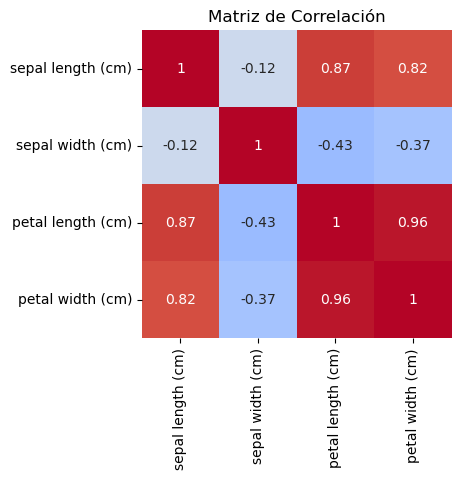

In [8]:
plt.figure(figsize = (4, 4))

sns.heatmap(matriz_correlacion, annot = True, cmap = 'coolwarm', vmin = -1, vmax = 1, cbar = False)
plt.title('Matriz de Correlación')
plt.show()

### 6.1. Pares de variables con correlación positiva fuerte.

Tenemos tres relaciones de variables con correlación positiva alta, las cuales son:

- Longitud de sépalo $\Leftrightarrow$ Longitud de pétalo ($\rho = 0.871$).
- Longitud de sépalo $\Leftrightarrow$ Ancho de pétalo ($\rho = 0.817$).
- Longitud de pétalo $\Leftrightarrow$ Ancho de pétalo ($\rho = 0.962$).

### 6.2. ¿Cómo estas correlaciones están relacionadas con las características de las diferentes especies de Iris?

No sé.

### 7. Repetír el análisis por especie.

In [9]:
dfs = {especie: datos.iloc[:, 0:4] for especie, datos in df_iris.groupby('species')}

In [10]:
matrices_correlacion = []

for i in range(len(dfs)):
    
    matrices_correlacion.append(dfs[i].corr(method = 'pearson'))

In [11]:
for i in range(len(dfs)):

    print(f"Matriz de Correlación de la especie {i}")
    
    display(matrices_correlacion[i].round(3))
    print("\n")

Matriz de Correlación de la especie 0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000,0.743,0.267,0.278
sepal width (cm),0.743,1.000,0.178,0.233
petal length (cm),0.267,0.178,1.000,0.332
petal width (cm),0.278,0.233,0.332,1.000




Matriz de Correlación de la especie 1


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000,0.526,0.754,0.546
sepal width (cm),0.526,1.000,0.561,0.664
petal length (cm),0.754,0.561,1.000,0.787
petal width (cm),0.546,0.664,0.787,1.000




Matriz de Correlación de la especie 2


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000,0.457,0.864,0.281
sepal width (cm),0.457,1.000,0.401,0.538
petal length (cm),0.864,0.401,1.000,0.322
petal width (cm),0.281,0.538,0.322,1.000


In [12]:
for i in range(len(dfs)):

    print(f'\nRelaciones con correlación alta de la especie {i}:')
    print(filtro(matrices_correlacion[i].round(3), 0.75))


Relaciones con correlación alta de la especie 0:
[]

Relaciones con correlación alta de la especie 1:
[('sepal length (cm)', 'petal length (cm)', np.float64(0.754)), ('petal length (cm)', 'petal width (cm)', np.float64(0.787))]

Relaciones con correlación alta de la especie 2:
[('sepal length (cm)', 'petal length (cm)', np.float64(0.864))]


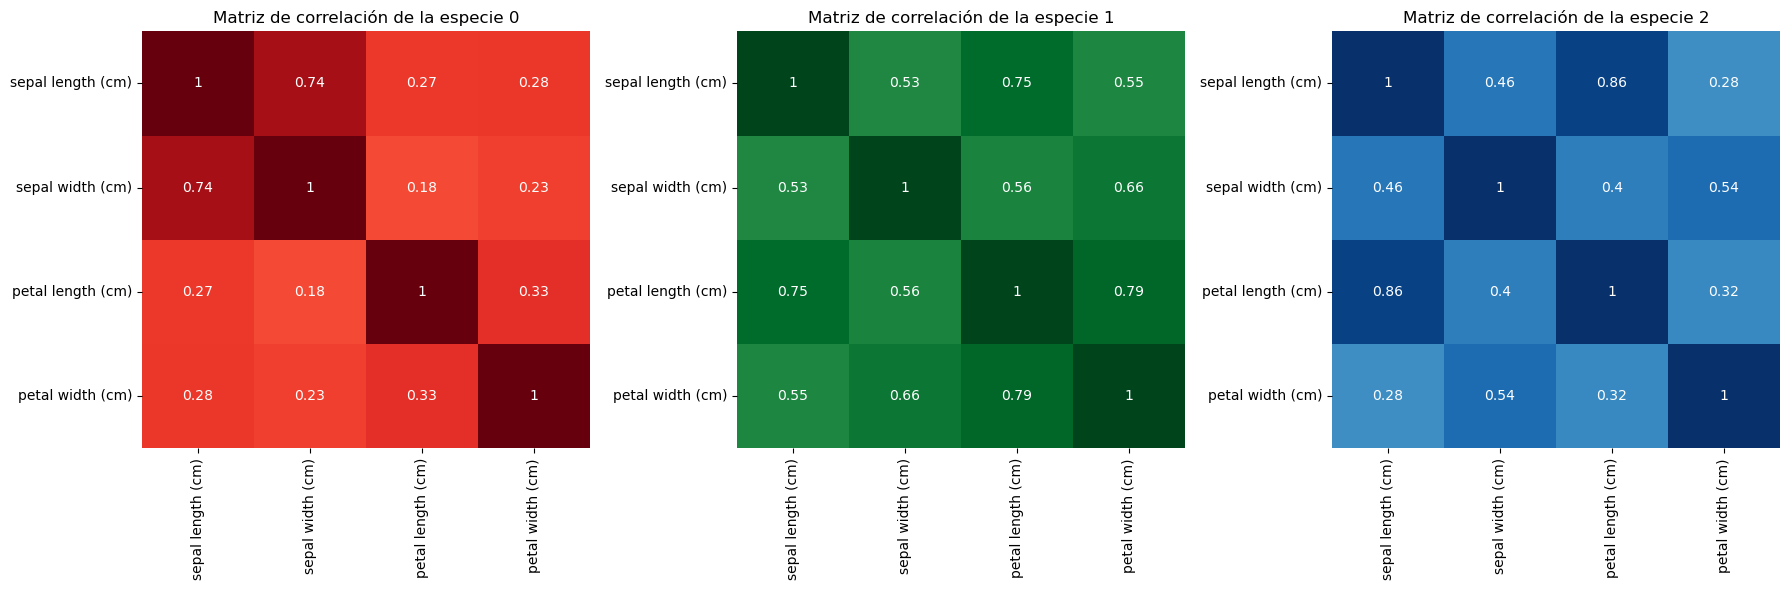

In [13]:
plt.figure(figsize = (18, 6))

colores = ['Reds', 'Greens', 'Blues']

for i, (matriz, color) in enumerate(zip(matrices_correlacion, colores)):
    
    plt.subplot(1, 3, i + 1)
    
    sns.heatmap(
        matriz,
        annot = True,
        cmap = color,
        vmin = -1,
        vmax = 1,
        cbar = False
    )
    
    plt.title(f'Matriz de correlación de la especie {i}')

plt.tight_layout()
plt.show()

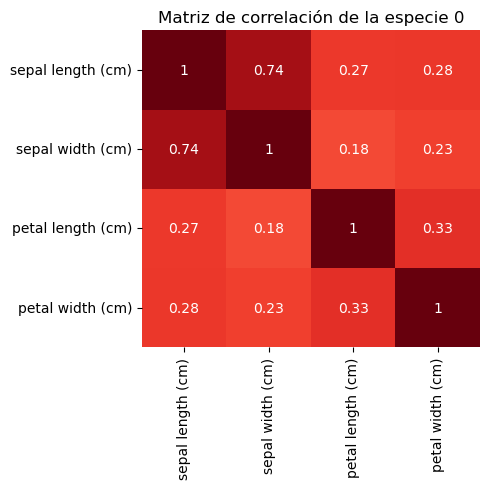

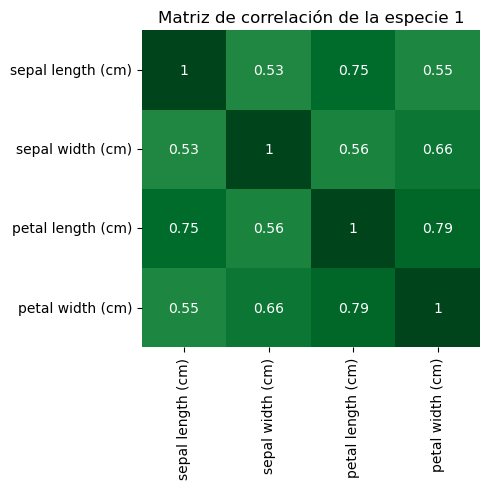

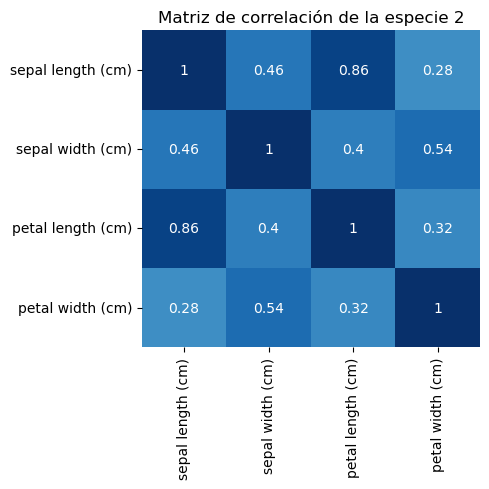

In [15]:
colores = ['Reds', 'Greens', 'Blues']

for i, (matriz, color) in enumerate(zip(matrices_correlacion, colores)):
    
    plt.figure(figsize = (5, 5)) 
    
    sns.heatmap(
        matriz,
        annot = True,
        cmap = color,
        vmin = -1,
        vmax = 1,
        cbar = False
    )
    
    plt.title(f'Matriz de correlación de la especie {i}')
    plt.tight_layout()
    
    plt.show()